# Bank Customer Risk Segmentation Using Expectation-Maximization

### Advanced Artificial Intelligence – Real-World EM Application

**Objective:** Discover hidden customer risk segments from observable financial and behavioral data using the **Expectation-Maximization (EM) algorithm** with a Gaussian Mixture Model (GMM) assumption.

### Important principle
- `bank_customer_em.csv` contains only observable features and is used for EM training.
- `bank_customer_ground_truth.csv` contains hidden/true risk labels and is used **only after clustering for validation**.
- `customer_id` is an identifier and is never used as a model feature.


## 1. Problem Statement

A bank observes customer attributes such as income, savings, credit utilization, debt burden, payment delays, missed payments, loan count, and transaction behavior. The underlying customer risk category is not directly observed.

We therefore model customer risk as a **latent variable** and use EM to estimate the probability that each customer belongs to each hidden component.

### Conceptual flow

Observed financial behavior → EM → latent customer risk → Low / Medium / High Risk

### EM steps
1. **E-Step:** estimate responsibilities, i.e. the posterior probability of each hidden component for each customer.
2. **M-Step:** update the mixture weights, Gaussian means, and covariance matrices using those responsibilities.
3. Repeat until the log-likelihood improvement becomes sufficiently small.



# 2. IMPORT LIBRARIES


In [1]:


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.special import logsumexp
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    adjusted_rand_score,
    normalized_mutual_info_score
)

import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
        
sns.set_theme(style='whitegrid')

print('Libraries imported successfully.')

Libraries imported successfully.



# 3. LOAD DATA


In [2]:


df_em = pd.read_csv('bank_customer_em.csv')
df_truth = pd.read_csv('bank_customer_ground_truth.csv')

print('=' * 70)
print('LOADING DATA')
print('=' * 70)

print('\nObservable Dataset Shape:', df_em.shape)
print('Ground Truth Dataset Shape:', df_truth.shape)
        
print('\nFirst 5 Rows:')
display(df_em.head())

print('\nData Types:')
display(df_em.dtypes)

print('\nMissing Values:')
display(df_em.isnull().sum())

print('\nDuplicate Rows:', df_em.duplicated().sum())

LOADING DATA

Observable Dataset Shape: (2000, 14)
Ground Truth Dataset Shape: (2000, 2)

First 5 Rows:


,customer_id,age,annual_income,monthly_expense,savings_balance,debt_to_income_ratio,credit_utilization,average_transaction_amount,monthly_transaction_count,payment_delay_days,missed_payment_count,active_loans,account_tenure_years,investment_amount
0,CUST0001,44,745700,54350,84300,0.70,65.8,3309,49,19.1,6,5,4.1,43500
1,CUST0002,31,1120800,38350,1397800,0.26,15.3,2668,33,0.0,0,2,10.0,2988400
2,CUST0003,27,1275500,40550,1173900,0.19,27.2,6907,26,3.6,3,1,12.5,244800
3,CUST0004,53,2853300,103850,1842800,0.23,29.8,3890,25,0.0,0,2,3.8,2661900
4,CUST0005,47,331400,24550,39500,0.63,89.2,1314,42,19.1,5,3,9.8,36300



Data Types:


customer_id                       str
age                             int64
annual_income                   int64
monthly_expense                 int64
savings_balance                 int64
debt_to_income_ratio          float64
credit_utilization            float64
average_transaction_amount      int64
monthly_transaction_count       int64
payment_delay_days            float64
missed_payment_count            int64
active_loans                    int64
account_tenure_years          float64
investment_amount               int64
dtype: object


Missing Values:


customer_id                   0
age                           0
annual_income                 0
monthly_expense               0
savings_balance               0
debt_to_income_ratio          0
credit_utilization            0
average_transaction_amount    0
monthly_transaction_count     0
payment_delay_days            0
missed_payment_count          0
active_loans                  0
account_tenure_years          0
investment_amount             0
dtype: int64


Duplicate Rows: 0


## 4. Data Cleaning

The observable dataset is cleaned before constructing the feature matrix so that the number and order of rows remain aligned with model predictions and the customer IDs.

In [4]:
df_em = (
    df_em
    .dropna()
    .drop_duplicates()
    .reset_index(drop=True)
)

df_truth = (
    df_truth
    .dropna()
    .drop_duplicates(subset=['customer_id'])
    .reset_index(drop=True)
)

print('Cleaned observable dataset shape:', df_em.shape)
print('Cleaned ground-truth dataset shape:', df_truth.shape)

Cleaned observable dataset shape: (2000, 14)
Cleaned ground-truth dataset shape: (2000, 2)



# 5. FEATURE SELECTION


In [5]:


feature_columns = [
    'age',
    'annual_income',
    'monthly_expense',
    'savings_balance',
    'debt_to_income_ratio',
    'credit_utilization',
    'average_transaction_amount',
    'monthly_transaction_count',
    'payment_delay_days',
    'missed_payment_count',
    'active_loans',
    'account_tenure_years',
    'investment_amount'
]

# customer_id is an identifier and must not be used as an ML feature.
X = df_em[feature_columns].astype(float).values

print('Number of ML features:', X.shape[1])
print('\nFeatures used by EM:')
for feature in feature_columns:
    print(' -', feature)

Number of ML features: 13

Features used by EM:
 - age
 - annual_income
 - monthly_expense
 - savings_balance
 - debt_to_income_ratio
 - credit_utilization
 - average_transaction_amount
 - monthly_transaction_count
 - payment_delay_days
 - missed_payment_count
 - active_loans
 - account_tenure_years
 - investment_amount


## 6. Exploratory Data Analysis (EDA)

The following plots inspect important financial and payment-behavior variables before clustering.

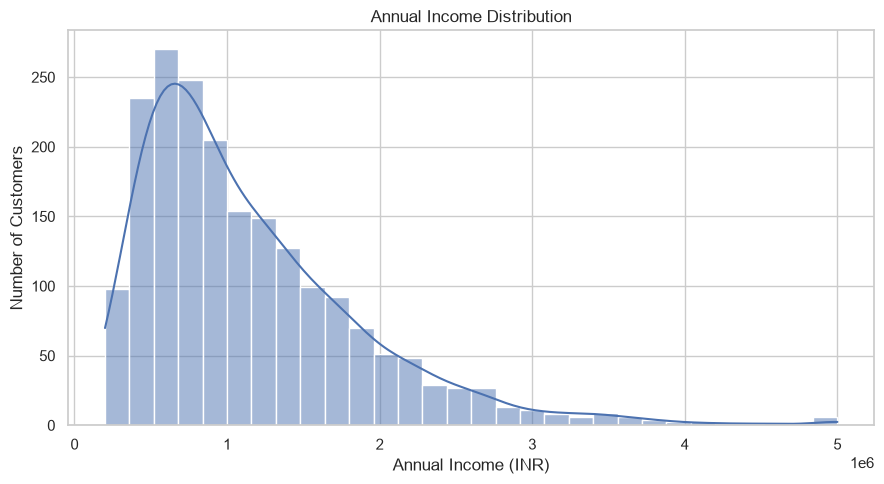

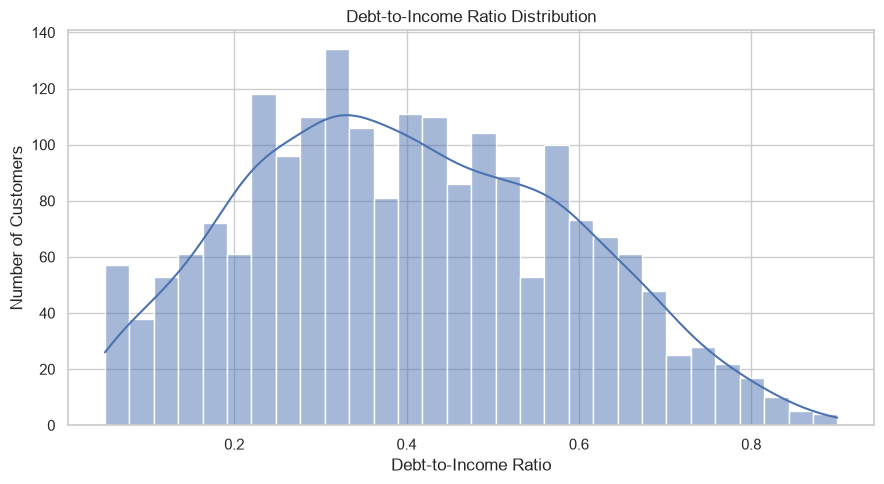

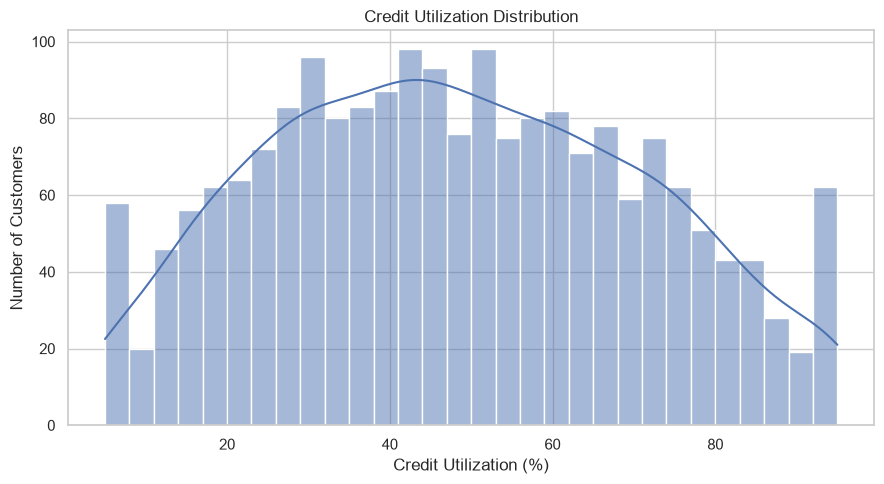

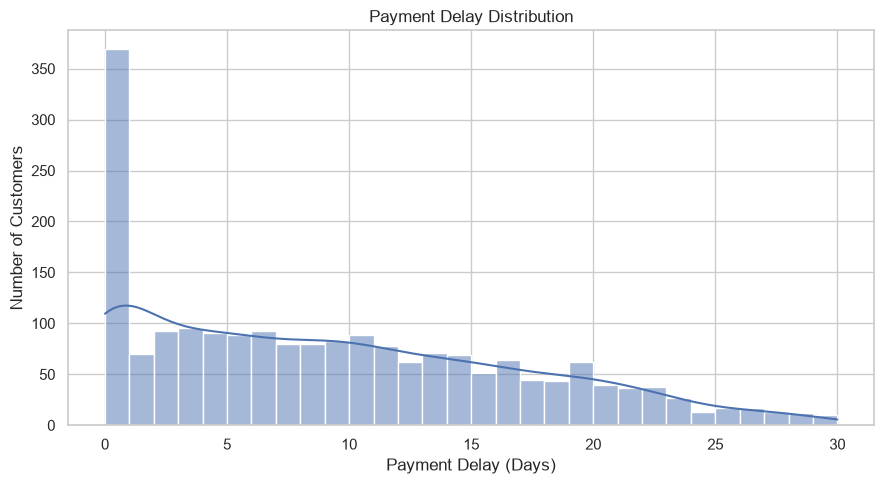

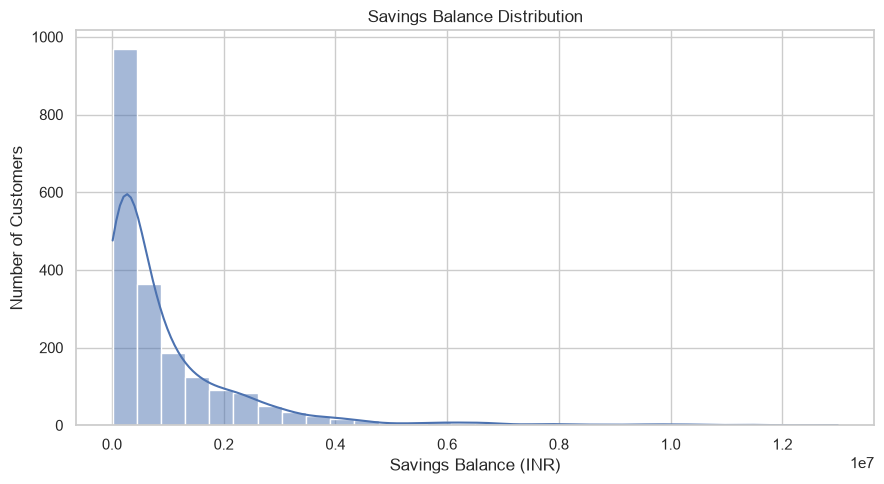

In [6]:
eda_columns = [
    ('annual_income', 'Annual Income Distribution', 'Annual Income (INR)'),
    ('debt_to_income_ratio', 'Debt-to-Income Ratio Distribution', 'Debt-to-Income Ratio'),
    ('credit_utilization', 'Credit Utilization Distribution', 'Credit Utilization (%)'),
    ('payment_delay_days', 'Payment Delay Distribution', 'Payment Delay (Days)'),
    ('savings_balance', 'Savings Balance Distribution', 'Savings Balance (INR)')
]

for column, title, xlabel in eda_columns:
    plt.figure(figsize=(9, 5))
    sns.histplot(df_em[column], bins=30, kde=True)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel('Number of Customers')
    plt.tight_layout()
    plt.show()

Descriptive Statistics:


,count,mean,std,min,25%,50%,75%,max
age,2000.0,39.73,9.51,21.00,33.00,40.00,46.00,69.0
annual_income,2000.0,1153066.40,734814.93,200000.00,622100.00,955200.00,1497975.00,5000000.0
monthly_expense,2000.0,48462.18,26616.76,10150.00,30150.00,41725.00,60100.00,224000.0
savings_balance,2000.0,995711.70,1410819.63,13200.00,171225.00,473900.00,1254525.00,12992100.0
debt_to_income_ratio,2000.0,0.40,0.18,0.05,0.26,0.39,0.54,0.9
credit_utilization,2000.0,48.17,22.85,5.00,30.20,47.00,65.62,95.0
average_transaction_amount,2000.0,3264.14,1503.29,702.00,2193.00,2993.50,3957.00,14189.0
monthly_transaction_count,2000.0,32.62,8.89,5.00,27.00,32.00,39.00,61.0
payment_delay_days,2000.0,9.34,7.67,0.00,2.60,8.25,14.80,30.0
missed_payment_count,2000.0,2.15,1.85,0.00,1.00,2.00,3.00,8.0


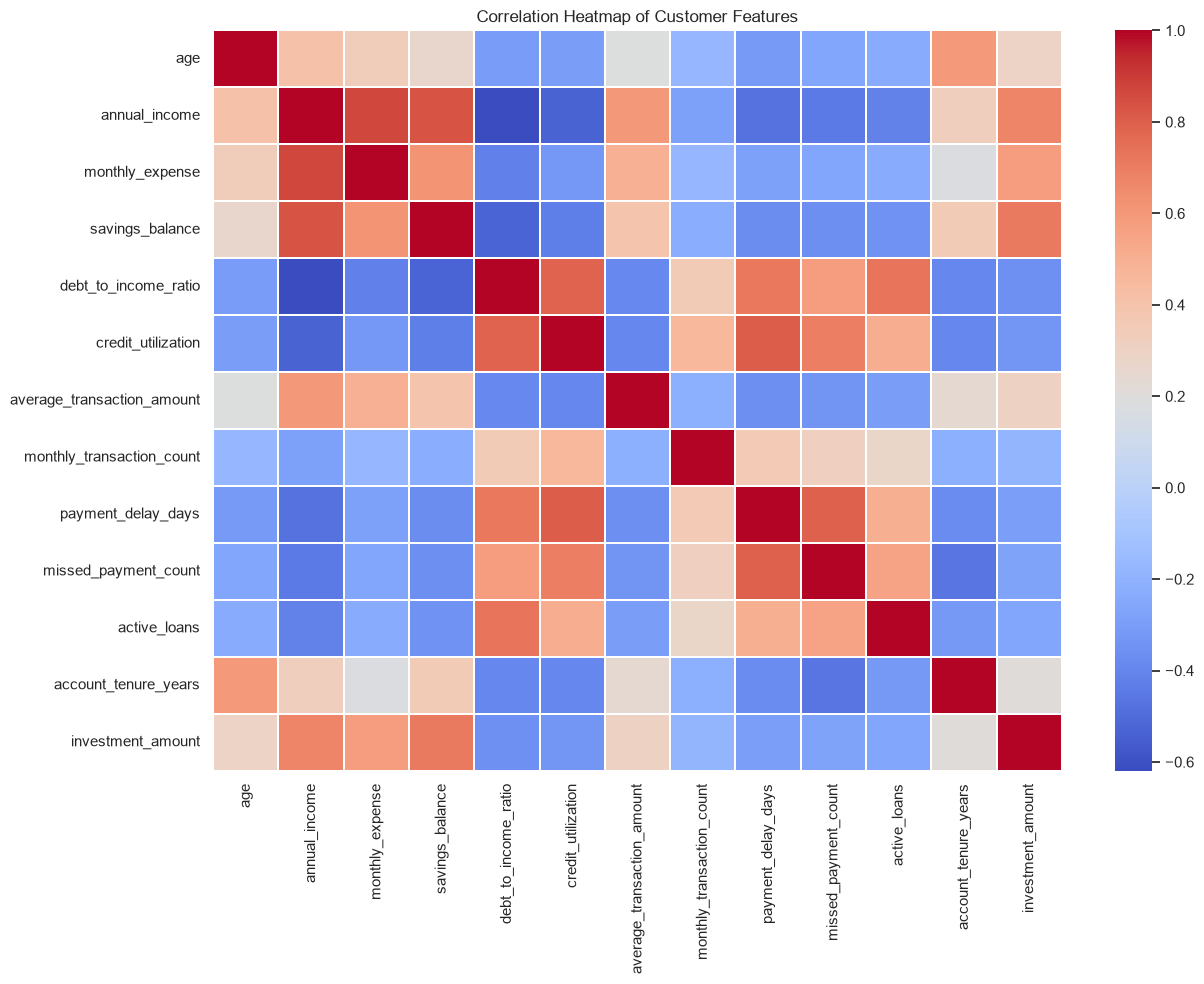

In [7]:
print('Descriptive Statistics:')
display(df_em[feature_columns].describe().T.round(2))

plt.figure(figsize=(13, 10))
sns.heatmap(
    df_em[feature_columns].corr(),
    annot=False,
    cmap='coolwarm',
    linewidths=0.2
)
plt.title('Correlation Heatmap of Customer Features')
plt.tight_layout()
plt.show()

## 8. Feature Standardization

The raw variables have very different scales (for example, annual income and transaction counts). Standardization prevents large-magnitude variables from dominating distance/covariance calculations.

We standardize each feature using:

$$z = \frac{x-\mu}{\sigma}$$

The EM model is trained using all standardized features. PCA is used only later for visualization.

In [8]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=feature_columns)

print('Standardization completed.')
print('\nScaled means:')
print(np.round(X_scaled.mean(axis=0), 4))
print('\nScaled standard deviations:')
print(np.round(X_scaled.std(axis=0), 4))

Standardization completed.

Scaled means:
[ 0.  0. -0.  0.  0. -0. -0.  0. -0.  0.  0.  0.  0.]

Scaled standard deviations:
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


## 9. EM Algorithm Theory

We assume the observations come from a mixture of three Gaussian components.

For customer $i$ and hidden component $k$, the E-Step computes the responsibility:

$$\gamma_{ik} = P(Z_i=k \mid X_i,\theta)$$

The M-Step updates:

$$N_k = \sum_i \gamma_{ik}$$

$$\pi_k = \frac{N_k}{N}$$

$$\mu_k = \frac{1}{N_k}\sum_i \gamma_{ik}X_i$$

$$\Sigma_k = \frac{1}{N_k}\sum_i \gamma_{ik}(X_i-\mu_k)(X_i-\mu_k)^T$$

The algorithm repeats E-Step → M-Step until convergence.


# 10. GAUSSIAN LOG-PROBABILITY


In [9]:
def gaussian_log_probability(X, mean, covariance, reg_covar=1e-5):
    """
    Log probability of samples under a multivariate Gaussian.
    Cholesky decomposition is used for numerical stability.
    """
    n_features = X.shape[1]

    covariance_reg = covariance + reg_covar * np.eye(n_features)
    L = np.linalg.cholesky(covariance_reg)

    diff = (X - mean).T
    solved = np.linalg.solve(L, diff)
    mahalanobis = np.sum(solved ** 2, axis=0)
    log_det = 2 * np.sum(np.log(np.diag(L)))

    return -0.5 * (
        n_features * np.log(2 * np.pi)
        + log_det
        + mahalanobis
    )


# 11. MANUAL EM IMPLEMENTATION


In [10]:
def run_em(
    X,
    n_components=3,
    max_iter=200,
    tolerance=1e-5,
    reg_covar=1e-5,
    random_state=42
):
    """Manual Expectation-Maximization for a Gaussian mixture model."""

    rng = np.random.default_rng(random_state)
    n_samples, n_features = X.shape

    # -----------------------------
    # Initialization
    # -----------------------------
    random_indices = rng.choice(
        n_samples, size=n_components, replace=False
    )
    means = X[random_indices].copy()
    weights = np.ones(n_components) / n_components

    global_covariance = np.cov(X, rowvar=False)
    global_covariance += reg_covar * np.eye(n_features)
    covariances = np.array([
        global_covariance.copy() for _ in range(n_components)
    ])

    log_likelihoods = []
    converged = False

    for iteration in range(1, max_iter + 1):

        # ========================================================
        # E-STEP
        # ========================================================
        log_joint = np.zeros((n_samples, n_components))

        for k in range(n_components):
            log_gaussian = gaussian_log_probability(
                X,
                means[k],
                covariances[k],
                reg_covar
            )

            log_joint[:, k] = (
                np.log(weights[k] + 1e-15)
                + log_gaussian
            )

        sample_log_likelihood = logsumexp(log_joint, axis=1)
        current_log_likelihood = np.sum(sample_log_likelihood)
        log_likelihoods.append(current_log_likelihood)

        # Posterior probabilities / responsibilities
        log_responsibilities = (
            log_joint
            - logsumexp(log_joint, axis=1, keepdims=True)
        )
        responsibilities = np.exp(log_responsibilities)

        # ========================================================
        # M-STEP
        # ========================================================
        Nk = np.maximum(responsibilities.sum(axis=0), 1e-12)

        new_weights = Nk / n_samples
        new_means = (responsibilities.T @ X) / Nk[:, None]
        new_covariances = np.zeros_like(covariances)

        for k in range(n_components):
            diff = X - new_means[k]
            weighted_diff = diff * responsibilities[:, k:k+1]
            covariance = (weighted_diff.T @ diff) / Nk[k]
            covariance += reg_covar * np.eye(n_features)
            new_covariances[k] = covariance

        weights = new_weights
        means = new_means
        covariances = new_covariances

        # ========================================================
        # CONVERGENCE CHECK
        # ========================================================
        if iteration > 1:
            improvement = log_likelihoods[-1] - log_likelihoods[-2]
            relative_improvement = (
                abs(improvement) / max(1.0, abs(log_likelihoods[-2]))
            )

            if relative_improvement < tolerance:
                converged = True
                break

    # Final E-Step using the final parameters
    final_log_joint = np.zeros((n_samples, n_components))

    for k in range(n_components):
        final_log_joint[:, k] = (
            np.log(weights[k] + 1e-15)
            + gaussian_log_probability(
                X,
                means[k],
                covariances[k],
                reg_covar
            )
        )

    final_log_responsibilities = (
        final_log_joint
        - logsumexp(final_log_joint, axis=1, keepdims=True)
    )

    final_responsibilities = np.exp(final_log_responsibilities)
    final_labels = final_responsibilities.argmax(axis=1)
    final_log_likelihood = np.sum(logsumexp(final_log_joint, axis=1))

    return {
        'weights': weights,
        'means': means,
        'covariances': covariances,
        'responsibilities': final_responsibilities,
        'labels': final_labels,
        'log_likelihoods': log_likelihoods,
        'converged': converged,
        'n_iter': len(log_likelihoods),
        'final_log_likelihood': final_log_likelihood
    }


# 12. TRAIN EM MODEL


In [11]:


em_result = run_em(
    X_scaled,
    n_components=3,
    max_iter=200,
    tolerance=1e-5,
    reg_covar=1e-5,
    random_state=RANDOM_STATE
)

print('=' * 70)
print('EM TRAINING RESULTS')
print('=' * 70)
print('Converged:', em_result['converged'])
print('Number of iterations:', em_result['n_iter'])
print('Final log-likelihood:', round(em_result['final_log_likelihood'], 4))
print('Mixing coefficients:', np.round(em_result['weights'], 4))

EM TRAINING RESULTS
Converged: True
Number of iterations: 86
Final log-likelihood: -19795.2871
Mixing coefficients: [0.4047 0.2285 0.3667]



# 13. EM CONVERGENCE PLOT


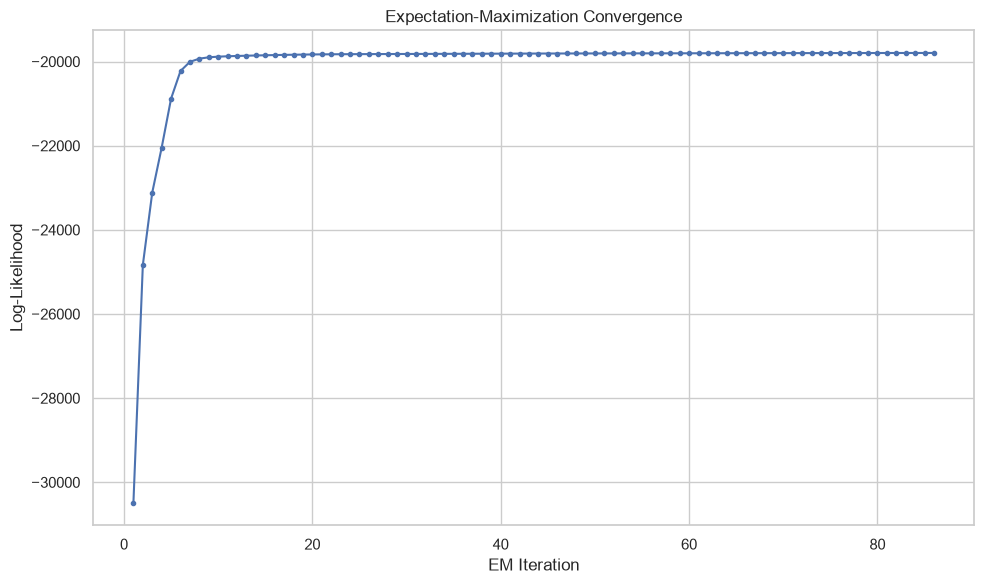

In [12]:
plt.figure(figsize=(10, 6))
plt.plot(
    range(1, len(em_result['log_likelihoods']) + 1),
    em_result['log_likelihoods'],
    marker='o',
    markersize=3
)
plt.title('Expectation-Maximization Convergence')
plt.xlabel('EM Iteration')
plt.ylabel('Log-Likelihood')
plt.grid(True)
plt.tight_layout()
plt.show()

## 14. E-Step Responsibilities

The E-Step produces a probability distribution over the three hidden Gaussian components for every customer. These probabilities are called **responsibilities**.

Example interpretation:

- Low-risk component: 0.10
- Medium-risk component: 0.25
- High-risk component: 0.65

The customer would be assigned to the component with the largest posterior probability.

In [14]:
responsibilities = em_result['responsibilities']

df_responsibilities = pd.DataFrame(
    responsibilities,
    columns=[
        'Cluster_0_Probability',
        'Cluster_1_Probability',
        'Cluster_2_Probability'
    ]
)

df_responsibilities.insert(
    0, 'customer_id', df_em['customer_id'].values
)

df_responsibilities['Predicted_Cluster'] = responsibilities.argmax(axis=1)

print('Sample E-Step Responsibilities:')
display(df_responsibilities.head(10).round(4))

Sample E-Step Responsibilities:


,customer_id,Cluster_0_Probability,Cluster_1_Probability,Cluster_2_Probability,Predicted_Cluster
0,CUST0001,0.0028,0.0000,0.9972,2
1,CUST0002,0.0000,1.0000,0.0000,1
2,CUST0003,0.9855,0.0145,0.0000,0
3,CUST0004,0.0000,1.0000,0.0000,1
4,CUST0005,0.0009,0.0000,0.9991,2
5,CUST0006,0.0002,0.0000,0.9998,2
6,CUST0007,0.0000,1.0000,0.0000,1
7,CUST0008,1.0000,0.0000,0.0000,0
8,CUST0009,0.0000,1.0000,0.0000,1
9,CUST0010,0.0015,0.0000,0.9985,2



# 15. FINAL CLUSTER ASSIGNMENTS


In [15]:


df_em['cluster'] = em_result['labels']
        
print('Cluster Distribution:')
display(df_em['cluster'].value_counts().sort_index())

Cluster Distribution:


cluster
0    808
1    451
2    741
Name: count, dtype: int64

## 16. Cluster Interpretation

Cluster IDs are arbitrary: EM does **not** know that cluster 0 means Low Risk, cluster 1 means Medium Risk, etc.

Therefore, we interpret the clusters using observable financial behavior.

### Risk indicators used for interpretation
**Higher risk:** debt-to-income ratio, credit utilization, payment delay, missed payments, active loans.

**Lower risk:** annual income, savings balance, investment amount.

This interpretation is performed **without using the ground-truth risk labels**.


# 17. CLUSTER PROFILES


In [16]:
profile_features = [
    'annual_income',
    'monthly_expense',
    'savings_balance',
    'debt_to_income_ratio',
    'credit_utilization',
    'payment_delay_days',
    'missed_payment_count',
    'active_loans',
    'investment_amount'
]

cluster_profile = (
    df_em[profile_features + ['cluster']]
    .groupby('cluster')
    .mean()
)

print('Cluster Mean Profiles:')
display(cluster_profile.T.round(2))

Cluster Mean Profiles:


cluster,0,1,2
annual_income,1140503.96,2140017.29,566069.91
monthly_expense,49108.42,75669.07,31198.38
savings_balance,713940.35,2885228.38,152930.63
debt_to_income_ratio,0.36,0.23,0.55
credit_utilization,42.15,30.73,65.35
payment_delay_days,7.08,4.44,14.78
missed_payment_count,1.65,1.03,3.37
active_loans,2.17,1.53,3.25
investment_amount,373974.26,1903738.58,54473.82



# 17. DATA-DRIVEN RISK MAPPING


In [17]:
bad_risk_features = [
    'debt_to_income_ratio',
    'credit_utilization',
    'payment_delay_days',
    'missed_payment_count',
    'active_loans'
]

good_risk_features = [
    'annual_income',
    'savings_balance',
    'investment_amount'
]

# Standardized cluster profile for comparable feature contributions
scaled_profile = (
    pd.DataFrame(X_scaled, columns=feature_columns)
    .assign(cluster=df_em['cluster'].values)
    .groupby('cluster')
    .mean()
)

# Higher score = more risky
risk_score = (
    scaled_profile[bad_risk_features].mean(axis=1)
    - scaled_profile[good_risk_features].mean(axis=1)
).sort_values()

print('Risk score by EM cluster (lower = safer):')
display(risk_score.round(4).to_frame('risk_score'))

ordered_clusters = risk_score.index.tolist()

mapping_dict = {
    ordered_clusters[0]: 'Low_Risk',
    ordered_clusters[1]: 'Medium_Risk',
    ordered_clusters[2]: 'High_Risk'
}

print('Cluster-to-risk mapping:')
for cluster, risk in mapping_dict.items():
    print(f'Cluster {cluster} -> {risk}')
        
df_em['predicted_risk_group'] = df_em['cluster'].map(mapping_dict)

Risk score by EM cluster (lower = safer):


,risk_score
cluster,
1,-1.9645
0,-0.1129
2,1.3188


Cluster-to-risk mapping:
Cluster 1 -> Low_Risk
Cluster 0 -> Medium_Risk
Cluster 2 -> High_Risk


## 18. PCA Visualization

PCA is used **only for visualization**. The EM algorithm itself is trained on all original standardized features.

Explained variance ratio: [0.4707 0.1394]
Total variance explained: 0.6101


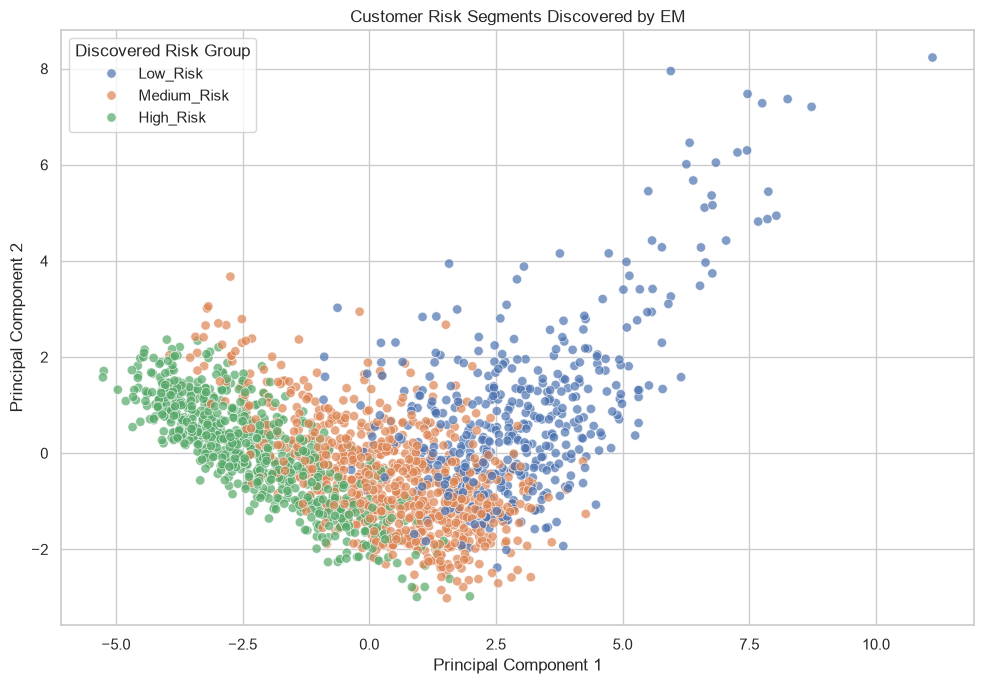

In [18]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df_em['PCA1'] = X_pca[:, 0]
df_em['PCA2'] = X_pca[:, 1]

print('Explained variance ratio:', np.round(pca.explained_variance_ratio_, 4))
print('Total variance explained:', round(pca.explained_variance_ratio_.sum(), 4))

plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=df_em,
    x='PCA1',
    y='PCA2',
    hue='predicted_risk_group',
    hue_order=['Low_Risk', 'Medium_Risk', 'High_Risk'],
    alpha=0.7,
    s=45
)
plt.title('Customer Risk Segments Discovered by EM')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Discovered Risk Group')
plt.tight_layout()
plt.show()

## 19. Ground-Truth Validation

Only now do we load and merge the ground-truth file. The true risk label was **not** used in EM training, parameter estimation, risk mapping, or cluster assignment.

In [19]:
df_final = pd.merge(
    df_em,
    df_truth,
    on='customer_id',
    how='inner',
    validate='one_to_one'
)

print('Validation dataset shape:', df_final.shape)

print('\nTrue Risk Distribution:')
display(df_final['true_risk_group'].value_counts())

print('\nPredicted Risk Distribution:')
display(df_final['predicted_risk_group'].value_counts())

Validation dataset shape: (2000, 19)

True Risk Distribution:


true_risk_group
Low_Risk       800
Medium_Risk    700
High_Risk      500
Name: count, dtype: int64


Predicted Risk Distribution:


predicted_risk_group
Medium_Risk    808
High_Risk      741
Low_Risk       451
Name: count, dtype: int64


# 20. CONFUSION MATRIX


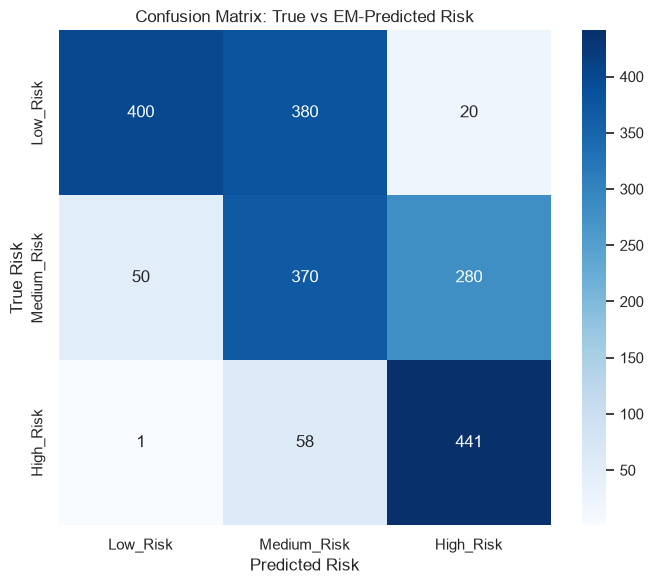

In [20]:


labels = ['Low_Risk', 'Medium_Risk', 'High_Risk']

cm = confusion_matrix(
    df_final['true_risk_group'],
    df_final['predicted_risk_group'],
    labels=labels
)

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=labels,
    yticklabels=labels
)
plt.title('Confusion Matrix: True vs EM-Predicted Risk')
plt.xlabel('Predicted Risk')
plt.ylabel('True Risk')
plt.tight_layout()
plt.show()


# 21. CLASSIFICATION METRICS


In [21]:


accuracy = accuracy_score(
    df_final['true_risk_group'],
    df_final['predicted_risk_group']
)

print('=' * 70)
print('CLASSIFICATION METRICS')
print('=' * 70)
print(f'Accuracy: {accuracy:.4f}')
        
print('\nClassification Report:')
print(classification_report(
    df_final['true_risk_group'],
    df_final['predicted_risk_group'],
    labels=labels,
    digits=4
))

CLASSIFICATION METRICS
Accuracy: 0.6055

Classification Report:
              precision    recall  f1-score   support

    Low_Risk     0.8869    0.5000    0.6395       800
 Medium_Risk     0.4579    0.5286    0.4907       700
   High_Risk     0.5951    0.8820    0.7107       500

    accuracy                         0.6055      2000
   macro avg     0.6467    0.6369    0.6136      2000
weighted avg     0.6638    0.6055    0.6052      2000




# 22. CLUSTERING METRICS


In [22]:


ari = adjusted_rand_score(
    df_final['true_risk_group'],
    df_final['cluster']
)

nmi = normalized_mutual_info_score(
    df_final['true_risk_group'],
    df_final['cluster']
)

print('=' * 70)
print('CLUSTERING METRICS')
print('=' * 70)
print(f'Adjusted Rand Index (ARI): {ari:.4f}')
print(f'Normalized Mutual Information (NMI): {nmi:.4f}')

CLUSTERING METRICS
Adjusted Rand Index (ARI): 0.2588
Normalized Mutual Information (NMI): 0.3232


## 23. Final Customer Risk Profile

EM provides **soft cluster membership**. The maximum responsibility is reported as the membership probability of the assigned cluster.

This should be described as a **cluster-membership probability**, not as a calibrated probability of real-world default.

In [23]:
df_final['cluster_membership_probability'] = responsibilities.max(axis=1)

df_final['Low_Risk_Probability'] = np.nan
df_final['Medium_Risk_Probability'] = np.nan
df_final['High_Risk_Probability'] = np.nan

for cluster, risk_name in mapping_dict.items():
    if risk_name == 'Low_Risk':
        df_final['Low_Risk_Probability'] = responsibilities[:, cluster]
    elif risk_name == 'Medium_Risk':
        df_final['Medium_Risk_Probability'] = responsibilities[:, cluster]
    elif risk_name == 'High_Risk':
        df_final['High_Risk_Probability'] = responsibilities[:, cluster]

final_columns = [
    'customer_id',
    'predicted_risk_group',
    'cluster_membership_probability',
    'Low_Risk_Probability',
    'Medium_Risk_Probability',
    'High_Risk_Probability',
    'annual_income',
    'debt_to_income_ratio',
    'credit_utilization',
    'payment_delay_days',
    'missed_payment_count',
    'active_loans'
]

final_profile_df = df_final[final_columns].copy()

print('Sample final customer profiles:')
display(final_profile_df.sample(10, random_state=RANDOM_STATE).round(4))

Sample final customer profiles:


,customer_id,predicted_risk_group,cluster_membership_probability,Low_Risk_Probability,Medium_Risk_Probability,High_Risk_Probability,annual_income,debt_to_income_ratio,credit_utilization,payment_delay_days,missed_payment_count,active_loans
1860,CUST1861,Medium_Risk,1.0000,0.0000,1.0000,0.0000,1320200,0.40,73.4,10.5,4,3
353,CUST0354,Medium_Risk,0.9979,0.0000,0.9979,0.0020,760200,0.53,80.7,21.3,3,4
1333,CUST1334,Medium_Risk,0.7756,0.2244,0.7756,0.0000,1232200,0.42,33.1,2.9,0,4
905,CUST0906,Low_Risk,1.0000,1.0000,0.0000,0.0000,1671300,0.38,26.1,4.4,0,1
1289,CUST1290,Low_Risk,0.9998,0.9998,0.0002,0.0000,1723000,0.19,33.8,0.9,1,2
1273,CUST1274,Medium_Risk,0.9778,0.0021,0.9778,0.0201,1031700,0.35,65.6,9.9,2,1
938,CUST0939,Medium_Risk,0.8392,0.1608,0.8392,0.0000,1333900,0.26,27.8,3.5,1,1
1731,CUST1732,High_Risk,0.9959,0.0000,0.0041,0.9959,906000,0.65,83.8,30.0,7,4
65,CUST0066,Medium_Risk,0.9868,0.0001,0.9868,0.0131,744100,0.58,61.1,16.3,2,3
1323,CUST1324,Medium_Risk,0.9863,0.0137,0.9863,0.0000,1365600,0.28,14.9,0.6,0,2



# 24. DETAILED SINGLE CUSTOMER EXAMPLE


In [24]:
example_customer = df_final.sample(1, random_state=RANDOM_STATE).iloc[0]

print('CUSTOMER:', example_customer['customer_id'])
print('Predicted Risk:', example_customer['predicted_risk_group'])
print(f"Low Risk Probability: {example_customer['Low_Risk_Probability']:.4f}")
print(f"Medium Risk Probability: {example_customer['Medium_Risk_Probability']:.4f}")
print(f"High Risk Probability: {example_customer['High_Risk_Probability']:.4f}")
print('Ground Truth:', example_customer['true_risk_group'])

CUSTOMER: CUST1861
Predicted Risk: Medium_Risk
Low Risk Probability: 0.0000
Medium Risk Probability: 1.0000
High Risk Probability: 0.0000
Ground Truth: Medium_Risk



# 25. SAVE RESULTS


In [25]:


df_final.to_csv('bank_customer_em_results.csv', index=False)
cluster_profile.to_csv('cluster_profile.csv')
df_responsibilities.to_csv('em_responsibilities.csv', index=False)
final_profile_df.to_csv('final_customer_risk_profile.csv', index=False)

print('Saved files:')
print('1. bank_customer_em_results.csv')
print('2. cluster_profile.csv')
print('3. em_responsibilities.csv')
print('4. final_customer_risk_profile.csv')

Saved files:
1. bank_customer_em_results.csv
2. cluster_profile.csv
3. em_responsibilities.csv
4. final_customer_risk_profile.csv


## Conclusion

This project demonstrates an end-to-end real-world application of the **Expectation-Maximization algorithm**:

Observed customer data → Standardization → E-Step → M-Step → Convergence → Latent clusters → Risk interpretation → Ground-truth validation.

The important academic point is that the hidden risk labels are **not used to train EM**.